© 2025 Mobile Perception Systems Lab at TU/e. All rights reserved. Licensed under the MIT License.

## Setup

In [1]:
# from google.colab import drive
# drive.mount("/content/drive", force_remount=True)

In [2]:
# Colab drive mount (skipped automatically when not on Colab)
try:
    from google.colab import drive
    drive.mount('/content/drive')
    get_ipython().run_line_magic('cd', '/content/drive/MyDrive/Project')
except (ImportError, ModuleNotFoundError):
    pass

In [3]:
# On Colab, cd into the eomt folder. Locally, run the notebook from this folder.
try:
    import google.colab  # noqa: F401
    get_ipython().run_line_magic('cd', '/content/drive/MyDrive/Project/MaskArchitectureAnomaly_CourseProject/eomt')
except (ImportError, ModuleNotFoundError):
    pass
# Install requirements
!pip install -r requirements.txt

In [4]:
import yaml
from lightning import seed_everything
import torch
from torch.nn import functional as F
from torch.amp.autocast_mode import autocast
import matplotlib.pyplot as plt
import numpy as np
from huggingface_hub import hf_hub_download
from huggingface_hub.utils import RepositoryNotFoundError
import warnings
import importlib

seed_everything(0, verbose=False)

# When running the final evaluation code, it is best to use a GPU
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

img_idx = 1  # change to the index of the image you want to visualize

MODEL_TYPE = "cityscapes"

config_path_cityscapes = "configs/dinov2/cityscapes/semantic/eomt_base_640.yaml"
state_dict_path_cityscapes = "../../eomt_cityscapes.bin"

config_path_coco = "configs/dinov2/coco/panoptic/eomt_base_640_2x.yaml"
state_dict_path_coco = "../../eomt_coco.bin"

with open(config_path_cityscapes, "r") as f:
    config_cs = yaml.safe_load(f)

with open(config_path_coco, "r") as f:
    config_coco = yaml.safe_load(f)


if MODEL_TYPE == "cityscapes":
    config = config_cs
    config_path = config_path_cityscapes
    state_dict_path = state_dict_path_cityscapes
else:
    config = config_coco
    config_path = config_path_coco
    state_dict_path = state_dict_path_coco

data_path = "../../cityscapes"  # change to the dataset directory

def create_mapping(images, ignore_index):
    unique_ids = np.unique(np.concatenate([np.unique(img) for img in images]))
    valid_ids = unique_ids[unique_ids != ignore_index]
    colors = np.array(
        [plt.cm.hsv(i / len(valid_ids))[:3] for i in range(len(valid_ids))]
    )
    mapping = {cid: colors[i] for i, cid in enumerate(valid_ids)}
    mapping[ignore_index] = np.array([0, 0, 0])
    return mapping


def apply_colormap(image, mapping):
    colored_image = np.zeros((*image.shape, 3))
    for cid in np.unique(image):
        colored_image[image == cid] = mapping.get(cid, [0, 0, 0])
    return colored_image

In [5]:
import json

def print_real_local_labels(json_path):
    with open(json_path, 'r') as f:
        data = json.load(f)

    print("\n 从本地数据集 JSON 中读取到的真实映射：")
    for cat in data['categories']:
        # isthing=1 代表 Things，0 代表 Stuff
        print(f"ID {cat['id']:03d} -> {cat['name']} (isthing: {cat['is_thing']})")

# 替换成你本地实际的 COCO 标注文件路径
# print_real_local_labels("path/to/annotations/panoptic_train2017.json")

## Load dataset

Ensure the dataset files are correctly prepared and placed in the folder specified by `data_path`.

In [6]:
if "coco" in config_path.lower():
    with open("configs/dinov2/cityscapes/semantic/eomt_base_640.yaml", "r") as f:
        config["data"] = yaml.safe_load(f)["data"]

data_module_name, class_name = config["data"]["class_path"].rsplit(".", 1)
data_module = getattr(importlib.import_module(data_module_name), class_name)
data_module_kwargs = config["data"].get("init_args", {})

data = data_module(
    path=data_path,
    batch_size=1,
    num_workers=0,
    check_empty_targets=False,
    **data_module_kwargs
).setup()

## Load model

In [7]:
warnings.filterwarnings(
    "ignore",
    message=r".*Attribute 'network' is an instance of `nn\.Module` and is already saved during checkpointing.*",
)

# Load encoder
encoder_cfg = config["model"]["init_args"]["network"]["init_args"]["encoder"]
encoder_module_name, encoder_class_name = encoder_cfg["class_path"].rsplit(".", 1)
encoder_cls = getattr(importlib.import_module(encoder_module_name), encoder_class_name)

# Preventing program crashes due to data size mismatch
is_loading_coco = "coco" in state_dict_path.lower()
eval_num_classes = 133 if is_loading_coco else data.num_classes
eval_img_size = (640, 640) if is_loading_coco else data.img_size

# encoder = encoder_cls(img_size=data.img_size, **encoder_cfg.get("init_args", {}))
encoder = encoder_cls(img_size=eval_img_size, **encoder_cfg.get("init_args", {}))

# Load network
network_cfg = config["model"]["init_args"]["network"]
network_module_name, network_class_name = network_cfg["class_path"].rsplit(".", 1)
network_cls = getattr(importlib.import_module(network_module_name), network_class_name)
network_kwargs = {k: v for k, v in network_cfg["init_args"].items() if k != "encoder"}
network = network_cls(
    masked_attn_enabled=False,
    num_classes=eval_num_classes, #Original: num_classes=data.num_classes,
    encoder=encoder,
    **network_kwargs,
)

# Load Lightning module
lit_module_name, lit_class_name = config["model"]["class_path"].rsplit(".", 1)
lit_cls = getattr(importlib.import_module(lit_module_name), lit_class_name)
model_kwargs = {k: v for k, v in config["model"]["init_args"].items() if k != "network"}
if "stuff_classes" in config["data"].get("init_args", {}):
    model_kwargs["stuff_classes"] = config["data"]["init_args"]["stuff_classes"]

# prevent initialization error in Cityscapes semantic mode.
if MODEL_TYPE == "cityscapes" and "stuff_classes" in model_kwargs:
    model_kwargs.pop("stuff_classes")

model = (
    lit_cls(
        img_size=eval_img_size,  #Original: img_size=data.img_size,寸
        num_classes=eval_num_classes,  #Original: num_classes=data.num_classes,
        network=network,
        **model_kwargs,
    )
    .eval()
    .to(device)
)

## Load pre-trained weights from Hugging Face Hub
The model weights are downloaded from the Hugging Face Hub using the logger name from the config. Make sure you have a working internet connection.

In [8]:
name = config.get("trainer", {}).get("logger", {}).get("init_args", {}).get("name")
if name is None:
    warnings.warn(
        "No logger name found in the config. Please specify a model name.")
else:
    try:

      # state_dict_path = hf_hub_download(
      #     repo_id=f"tue-mps/{name}",
      #     filename="pytorch_model.bin",
      # )
      is_dinov3 = "dinov3" in name

      if is_dinov3:
        model_kwargs["ckpt_path"] = state_dict_path
        model_kwargs["delta_weights"] = True

      # switch initialization based on coco/cityscapes
      is_loading_coco = "coco" in state_dict_path.lower()
      eval_num_classes = 133 if is_loading_coco else data.num_classes
      eval_img_size = (640, 640) if is_loading_coco else data.img_size

      model = (
          lit_cls(
              img_size=eval_img_size,      #Original:img_size=data.img_size,
              num_classes=eval_num_classes,  #Original:num_classes=data.num_classes,
              network=network,
              **model_kwargs,
          )
            .eval()
            .to(device)
      )

      if not is_dinov3:
        state_dict = torch.load(
          state_dict_path, map_location=device, weights_only=True
        )
        model.load_state_dict(state_dict, strict=False)

    except RepositoryNotFoundError:
        warnings.warn(
            f"Pre-trained model not found for `{name}`. Please load your own checkpoint."
        )

## Semantic inference (pixel-wise classification)

> This inference method also works when applied to a model trained for panoptic segmentation.

Semantic inference computes per-pixel class scores by combining mask and class predictions:

$$
\sum_i p_i(c) \cdot m_i[h, w]
$$

Here, $p_i(c)$ is the class probability for class $c$ (excluding "no object"), and $m_i[h, w]$ is the sigmoid-normalized mask value for query $i$ at pixel $(h, w)$. The final class is selected by taking the argmax over classes.  
  
*This inference method was originally introduced in MaskFormer.*

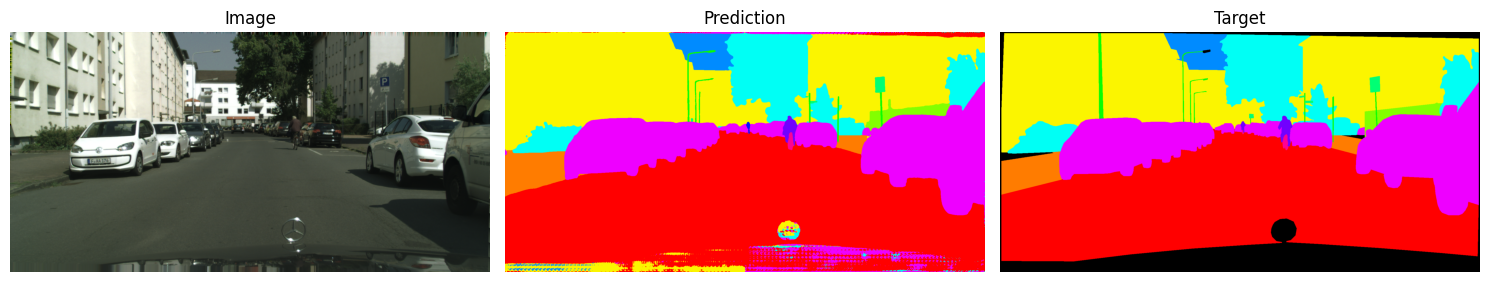

In [9]:
IGNORE_INDEX = 255


def infer_semantic(img, target):
    with torch.no_grad(), autocast(dtype=torch.float16, device_type="cuda"):
        imgs = [img.to(device)]
        img_sizes = [img.shape[-2:] for img in imgs]
        crops, origins = model.window_imgs_semantic(imgs)

        mask_logits_per_layer, class_logits_per_layer = model(crops)
        mask_logits = F.interpolate(
            mask_logits_per_layer[-1], data.img_size, mode="bilinear"
        )

        crop_logits = model.to_per_pixel_logits_semantic(
            mask_logits, class_logits_per_layer[-1]
        )
        logits = model.revert_window_logits_semantic(crop_logits, origins, img_sizes)
        preds = logits[0].argmax(0).cpu()

    pred_array = preds.numpy()
    target_array = model.to_per_pixel_targets_semantic([target], IGNORE_INDEX)[
        0
    ].numpy()
    return pred_array, target_array


def plot_semantic_results(img, pred_array, target_array):
    mapping = create_mapping([pred_array, target_array], IGNORE_INDEX)

    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    axes[0].imshow(img.permute(1, 2, 0).cpu().numpy())
    axes[0].set_title("Image")
    axes[1].imshow(apply_colormap(pred_array, mapping))
    axes[1].set_title("Prediction")
    axes[2].imshow(apply_colormap(target_array, mapping))
    axes[2].set_title("Target")

    for ax in axes:
        ax.axis("off")

    plt.tight_layout()
    plt.show()


img, target = data.val_dataloader().dataset[img_idx]
pred_array, target_array = infer_semantic(img, target)
plot_semantic_results(img, pred_array, target_array)

## Panoptic inference (segmentation with instance IDs)

> This inference method also works when applied to a model trained for instance segmentation.

Panoptic inference assigns each pixel $[h, w]$ to the query $i$ that maximizes the product of class and mask confidence:

$$
p_i(c_i) \cdot m_i[h, w]
$$

where $c_i = \arg\max_c \, p_i(c)$ is the most likely class for query $i$. A pixel is assigned to a query only if both the class confidence and mask confidence are high. Pixels assigned to the same query form a segment labeled with $c_i$. "Stuff" segments with the same class are merged; "thing" segments are kept distinct using the query index. Low-confidence and heavily occluded predictions are filtered out.  
  
*This inference method was originally introduced in MaskFormer.*

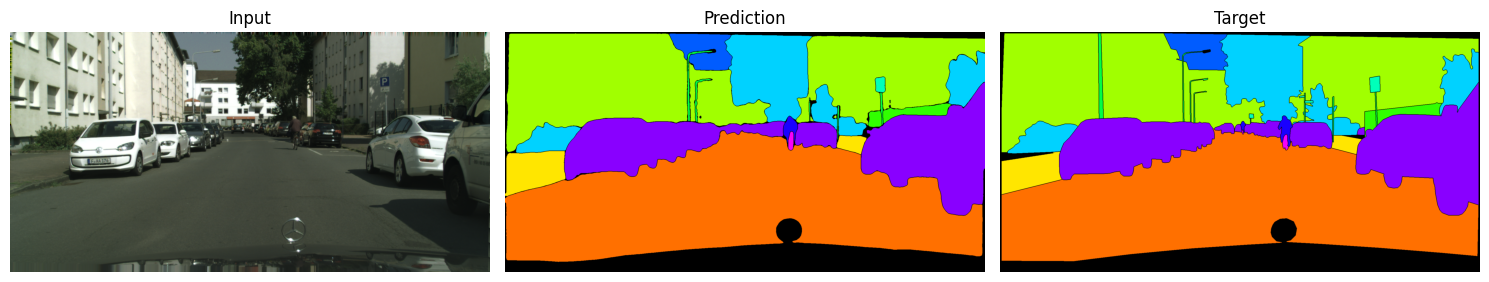

In [10]:
def infer_panoptic(img, target):
    with torch.no_grad(), autocast(dtype=torch.float16, device_type="cuda"):
        imgs = [img.to(device)]
        img_sizes = [img.shape[-2:] for img in imgs]

        transformed_imgs = model.resize_and_pad_imgs_instance_panoptic(imgs)
        mask_logits_per_layer, class_logits_per_layer = model(transformed_imgs)
        mask_logits = F.interpolate(
            mask_logits_per_layer[-1], model.img_size, mode="bilinear"
        )
        mask_logits = model.revert_resize_and_pad_logits_instance_panoptic(
            mask_logits, img_sizes
        )

        preds = model.to_per_pixel_preds_panoptic(
            mask_logits,
            class_logits_per_layer[-1],
            model.stuff_classes,
            model.mask_thresh,
            model.overlap_thresh,
        )[0].cpu()

    pred = preds.numpy()
    sem_pred, inst_pred = pred[..., 0], pred[..., 1]

    target_seg = model.to_per_pixel_targets_panoptic([target])[0].cpu().numpy()
    sem_target, inst_target = target_seg[..., 0], target_seg[..., 1]

    return sem_pred, inst_pred, sem_target, inst_target


def draw_black_border(sem, inst, mapping):




    h, w = sem.shape
    out = np.zeros((h, w, 3))
    for s in np.unique(sem):
        out[sem == s] = mapping[s]

    combined = sem.astype(np.int64) * 100000 + inst.astype(np.int64)
    border = np.zeros((h, w), dtype=bool)
    border[1:, :] |= combined[1:, :] != combined[:-1, :]
    border[:-1, :] |= combined[1:, :] != combined[:-1, :]
    border[:, 1:] |= combined[:, 1:] != combined[:, :-1]
    border[:, :-1] |= combined[:, 1:] != combined[:, :-1]
    out[border] = 0
    return out


def plot_panoptic_results(img, sem_pred, inst_pred, sem_target, inst_target):
    all_ids = np.union1d(np.unique(sem_pred), np.unique(sem_target))
    mapping = {
        s: (
            [0, 0, 0]
            if s == -1 or s == model.num_classes
            else plt.cm.hsv(i / len(all_ids))[:3]
        )
        for i, s in enumerate(all_ids)
    }

    vis_pred = draw_black_border(sem_pred, inst_pred, mapping)
    vis_target = draw_black_border(sem_target, inst_target, mapping)

    img_np = (
        img.cpu().numpy().transpose(1, 2, 0) if img.dim() == 3 else img.cpu().numpy()
    )

    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    axes[0].imshow(img_np)
    axes[0].set_title("Input")
    axes[1].imshow(vis_pred)
    axes[1].set_title("Prediction")
    axes[2].imshow(vis_target)
    axes[2].set_title("Target")

    for ax in axes:
        ax.axis("off")

    plt.tight_layout()
    plt.show()


img, target = data.val_dataloader().dataset[img_idx]
sem_pred, inst_pred, sem_target, inst_target = infer_panoptic(img, target)
plot_panoptic_results(img, sem_pred, inst_pred, sem_target, inst_target)


### Cross-Dataset Semantic Segmentation Evaluation

| Class | Cityscapes Labels & TrainID | COCO Labels & ID |
| :--- | :--- | :--- |
| **Flat** | road (0), sidewalk (1) | road (100), pavement-merged (123) |
| **Construction** | building (2), wall (3), fence (4) | bridge (82), house (91), roof (101), stairs (106), wall-brick (109), wall-stone (110), wall-tile (111), wall-wood (112), fence-merged (117), building-other-merged (129), wall-other-merged (131) |
| **Object** | pole (5), traffic light (6), traffic sign (7) | traffic light (9), fire hydrant (10), stop sign (11), parking meter (12) |
| **Nature** | vegetation (8), terrain (9) | flower (88), gravel (90), river (99), sand (102), sea (103), snow (105), water-other (113), tree-merged (116), mountain-merged (124), grass-merged (125), dirt-merged (126), rock-merged (130) |
| **Sky** | sky (10) | sky-other-merged (119) |
| **Human** | person (11), rider (12) | person (0) |
| **Vehicle** | car (13), truck (14), bus (15), train (16), motorcycle (17), bicycle (18) | bicycle (1), car (2), motorcycle (3), bus (5), train (6), truck (7) |
| **Ignore** | *All other remaining classes* | *All other remaining classes (e.g., airplane (4), boat (8), bench (13), animals, indoor objects...)* |

In [11]:
import sys
import gc

EVAL_NUM_CLASSES = 7
IGNORE_INDEX = 255

# Cityscapes TrainID -> 7 Macro-Class Mapping
CS_TRAINID_TO_7CLASS = {
    0: 0, 1: 0,                  # Flat: road, sidewalk
    2: 1, 3: 1, 4: 1,            # Construction: building, wall, fence
    5: 2, 6: 2, 7: 2,            # Object: pole, traffic light, traffic sign
    8: 3, 9: 3,                  # Nature: vegetation, terrain
    10: 4,                       # Sky: sky
    11: 5, 12: 5,                # Human: person, rider
    13: 6, 14: 6, 15: 6, 16: 6, 17: 6, 18: 6  # Vehicle: car, truck, bus, train, motorcycle, bicycle
}

# COCO ID -> 7 Macro-Class Mapping (Default to IGNORE_INDEX)
COCO_TO_7CLASS = {i: IGNORE_INDEX for i in range(133)}

# 修正后的 COCO_ID -> 7 Macro-Class 映射
coco_mapping_updates = {
    # 0: Flat (road, pavement-merged)
    100: 0, 123: 0,

    # 1: Construction (bridge, house, roof, stairs, wall-brick, wall-stone, wall-tile, wall-wood, fence-merged, building-other-merged, wall-other-merged)
    82: 1, 91: 1, 101: 1, 106: 1, 109: 1, 110: 1, 111: 1, 112: 1, 117: 1, 129: 1, 131: 1,

    # 2: Object (traffic light, fire hydrant, stop sign, parking meter)
    9: 2, 10: 2, 11: 2, 12: 2,

    # 3: Nature (flower, gravel, river, sand, sea, snow, water-other, tree-merged, mountain-merged, grass-merged, dirt-merged, rock-merged)
    88: 3, 90: 3, 99: 3, 102: 3, 103: 3, 105: 3, 113: 3, 116: 3, 124: 3, 125: 3, 126: 3, 130: 3,

    # 4: Sky (sky-other-merged)
    119: 4,

    # 5: Human (person)
    0: 5,

    # 6: Vehicle (bicycle, car, motorcycle, bus, train, truck)
    1: 6, 2: 6, 3: 6, 5: 6, 6: 6, 7: 6
}

COCO_TO_7CLASS.update(coco_mapping_updates)

COCO_MACRO_GROUPS = {macro_id: [] for macro_id in range(EVAL_NUM_CLASSES)}
for coco_id, macro_id in COCO_TO_7CLASS.items():
    if macro_id != IGNORE_INDEX:
        COCO_MACRO_GROUPS[macro_id].append(coco_id)

CS_MACRO_GROUPS = {macro_id: [] for macro_id in range(EVAL_NUM_CLASSES)}
for cs_id, macro_id in CS_TRAINID_TO_7CLASS.items():
    if macro_id != IGNORE_INDEX:
        CS_MACRO_GROUPS[macro_id].append(cs_id)

TARGET_LOOKUP_TABLE = np.full(256, IGNORE_INDEX, dtype=np.uint8)
for cs_id, macro_id in CS_TRAINID_TO_7CLASS.items():
    TARGET_LOOKUP_TABLE[cs_id] = macro_id


# Reference: The Cityscapes Dataset for Semantic Urban Scene Understanding
# Official evaluation protocol: Retain 19 core test classes (CITYSCAPES_NUM_CLASSES) after removing rare classes,
# and set ill-defined background to 255 (IGNORE_INDEX) to ignore during evaluation.

# MSeg: A Composite Dataset for Multi-domain Semantic Segmentation
# Taxonomy Alignment: When performing cross-dataset evaluation,
# extract the shared manifold regions between COCO and Cityscapes to unify the underlying label space.

def build_model_instance(target_config, target_state_dict_path, data_module_instance, device="cuda"):
    is_coco = "coco" in target_state_dict_path.lower()

    if is_coco and "data" not in target_config:
        with open("configs/dinov2/cityscapes/semantic/eomt_base_640.yaml", "r") as f:
            target_config["data"] = yaml.safe_load(f)["data"]

    # Encoder
    enc_cfg = target_config["model"]["init_args"]["network"]["init_args"]["encoder"]
    enc_mod_name, enc_cls_name = enc_cfg["class_path"].rsplit(".", 1)
    enc_cls = getattr(importlib.import_module(enc_mod_name), enc_cls_name)

    eval_num_classes = 133 if is_coco else data_module_instance.num_classes
    eval_img_size = (640, 640) if is_coco else data_module_instance.img_size

    encoder_obj = enc_cls(img_size=eval_img_size, **enc_cfg.get("init_args", {}))

    # Network
    net_cfg = target_config["model"]["init_args"]["network"]
    net_mod_name, net_cls_name = net_cfg["class_path"].rsplit(".", 1)
    net_cls = getattr(importlib.import_module(net_mod_name), net_cls_name)
    net_kwargs = {k: v for k, v in net_cfg["init_args"].items() if k != "encoder"}

    network_obj = net_cls(
        masked_attn_enabled=False,
        num_classes=eval_num_classes,
        encoder=encoder_obj,
        **net_kwargs,
    )

    # Lit Module
    lit_mod_name, l_cls_name = target_config["model"]["class_path"].rsplit(".", 1)
    lit_cls_obj = getattr(importlib.import_module(lit_mod_name), l_cls_name)
    m_kwargs = {k: v for k, v in target_config["model"]["init_args"].items() if k != "network"}

    if "stuff_classes" in target_config.get("data", {}).get("init_args", {}):
        m_kwargs["stuff_classes"] = target_config["data"]["init_args"]["stuff_classes"]

    if not is_coco and "stuff_classes" in m_kwargs:
        m_kwargs.pop("stuff_classes")

    constructed_model = (
        lit_cls_obj(
            img_size=eval_img_size,
            num_classes=eval_num_classes,
            network=network_obj,
            **m_kwargs,
        )
        .eval()
        .to(device)
    )

    return constructed_model, eval_img_size

def compute_confusion_matrix(pred, target, num_classes, ignore_index):
    mask = (target >= 0) & (target < num_classes) & (target != ignore_index)
    hist = np.bincount(
        num_classes * target[mask].astype(int) + pred[mask].astype(int),
        minlength=num_classes ** 2,
    ).reshape(num_classes, num_classes)
    return hist

def evaluate_semantic_mIoU_simplified(model, dataloader, img_size, is_coco_model=False, device="cuda"):
    model.eval()
    total_hist = np.zeros((EVAL_NUM_CLASSES, EVAL_NUM_CLASSES))

    if dataloader is None:
        raise ValueError("The provided dataloader is None, check data initialization!")

    raw_dev_str = device.type if isinstance(device, torch.device) else str(device)
    dev_type = "cuda" if "cuda" in raw_dev_str else "cpu"

    with torch.no_grad():
        for i, batch in enumerate(dataloader):

            if i % 100 == 0:
                print(f"Processing: Image [{i}/{len(dataloader)}] for full validation...")

            if isinstance(batch, list) or isinstance(batch, tuple):
                if len(batch) == 1 and isinstance(batch[0], dict):
                    batch = batch[0]
                elif len(batch) >= 2:
                    img, target = batch[0][0], batch[1][0]
                    batch = None

            if batch is not None and isinstance(batch, dict):
                img = batch.get('image', batch.get('img'))[0]
                target = batch.get('mask', batch.get('target'))[0]

            imgs = [img.to(device)]
            img_sizes = [img.shape[-2:] for img in imgs]

            with torch.amp.autocast(dtype=torch.float16, device_type=dev_type):
                crops, origins = model.window_imgs_semantic(imgs)
                # Masked-attention Mask Transformer for Universal Image Segmentation
                # Decouples the network output into independent "binary masks (mask_logits)" and "global categories (class_logits)"
                mask_logits, class_logits = model(crops)
                mask_logits_up = F.interpolate(mask_logits[-1], img_size, mode="bilinear")
                # Semantic Inference: Combines decoupled mask embeddings with pixel embeddings via matrix dot product.
                crop_logits = model.to_per_pixel_logits_semantic(mask_logits_up, class_logits[-1])
                logits = model.revert_window_logits_semantic(crop_logits, origins, img_sizes)[0]

            mapped_logits = torch.full((EVAL_NUM_CLASSES, logits.shape[1], logits.shape[2]), -float('inf'), device=logits.device, dtype=logits.dtype)

            if is_coco_model:
                # Attention Is All You Need (Vaswani et al., 2017)
                # Logit Masking: Initialize the tensor with -inf to form an absolute hard mask during the Argmax stage
                # LSeg/ OVSeg(Open-Vocabulary Semantic Segmentation with Mask-adapted CLIP)
                # Restricted Vocabulary Evaluation
                # Enforces constrained decoding, allowing the model to compete only within the mapped subset of 8 shared classes.
                for macro_id, coco_ids in COCO_MACRO_GROUPS.items():
                    if coco_ids:
                        mapped_logits[macro_id] = logits[coco_ids].max(dim=0)[0]
                pred_array = mapped_logits.argmax(0).cpu().numpy()
            else:
                for macro_id, cs_ids in CS_MACRO_GROUPS.items():
                    if cs_ids:
                        mapped_logits[macro_id] = logits[cs_ids].max(dim=0)[0]
                pred_array = mapped_logits.argmax(0).cpu().numpy()

            target_array = model.to_per_pixel_targets_semantic([target], IGNORE_INDEX)[0].cpu().numpy().copy()
            target_array[(target_array < 0) | (target_array > 255)] = IGNORE_INDEX
            target_array = TARGET_LOOKUP_TABLE[target_array.astype(np.uint8)]

            total_hist += compute_confusion_matrix(pred_array, target_array, EVAL_NUM_CLASSES, IGNORE_INDEX)

            del crops, mask_logits, class_logits, mask_logits_up, crop_logits, logits, mapped_logits

    intersection = np.diag(total_hist)
    union = total_hist.sum(axis=1) + total_hist.sum(axis=0) - intersection
    iou_per_class = intersection / (union + 1e-10)

    shared_class_ious = {macro_id: iou_per_class[macro_id] for macro_id in range(EVAL_NUM_CLASSES) if union[macro_id] > 0}

    print("\n IoU Results:")
    for cs_id, iou in shared_class_ious.items():
        print(f"Class {cs_id}: {iou*100:.2f}%")

    return np.mean(list(shared_class_ious.values())) if shared_class_ious else 0.0

def evaluate_checkpoint(target_config, target_state_dict_path, data_loader_instance, device, model_type="cityscapes"):

    is_coco = "coco" in target_state_dict_path.lower() or model_type in ["coco", "finetuned"]

    print(f"\n" + "="*60)
    print(f"Evaluating {model_type.upper()} Model")
    print("="*60)

    try:
        model, img_size = build_model_instance(target_config, target_state_dict_path, data_loader_instance, device=device)

        checkpoint = torch.load(target_state_dict_path, map_location=device, weights_only=True)
        if isinstance(checkpoint, dict) and 'state_dict' in checkpoint:
            model.load_state_dict(checkpoint['state_dict'], strict=False)
        else:
            model.load_state_dict(checkpoint, strict=False)

        val_dataloader = data_loader_instance.val_dataloader()

        mIoU = evaluate_semantic_mIoU_simplified(
            model=model,
            dataloader=val_dataloader,
            img_size=img_size,
            is_coco_model=is_coco,
            device=device
        )
        return mIoU
    except Exception as e:
        print(f"Failed to evaluate {model_type} model: {e}")
        return 0.0

if __name__ == "__main__":
    data_module_name, class_name = config_cs["data"]["class_path"].rsplit(".", 1)
    data_module = getattr(importlib.import_module(data_module_name), class_name)
    data_loader_instance = data_module(
        path=data_path,
        batch_size=1,
        num_workers=0,
        check_empty_targets=False,
        **config_cs["data"].get("init_args", {})
    )
    data_loader_instance.setup()
    val_dataloader = data_loader_instance.val_dataloader()


    # Evaluate Cityscapes
    mIoU_cs = evaluate_checkpoint(config_cs, state_dict_path_cityscapes, data_loader_instance, device, model_type="cityscapes")
    mIoU_coco = evaluate_checkpoint(config_coco, state_dict_path_coco, data_loader_instance, device, model_type="coco")

    print(f"Shared-Class Manifold Constraint Applied")
    print(f"Cityscapes Model: {mIoU_cs*100:.2f}%" if mIoU_cs > 0 else "Cityscapes Model mIoU : N/A (Failed)")
    print(f"COCO Zero-Shot: {mIoU_coco*100:.2f}%")

    if torch.cuda.is_available():
        torch.cuda.empty_cache()
    gc.collect()

    if 'val_dataloader' in locals() and hasattr(val_dataloader, '_iterator') and val_dataloader._iterator is not None:
        val_dataloader._iterator._shutdown_workers()


Evaluating CITYSCAPES Model
Processing: Image [0/500] for full validation...
Processing: Image [100/500] for full validation...
Processing: Image [200/500] for full validation...
Processing: Image [300/500] for full validation...
Processing: Image [400/500] for full validation...

 IoU Results:
Class 0: 98.78%
Class 1: 94.27%
Class 2: 76.58%
Class 3: 93.51%
Class 4: 95.54%
Class 5: 85.88%
Class 6: 94.68%

Evaluating COCO Model
Processing: Image [0/500] for full validation...
Processing: Image [100/500] for full validation...
Processing: Image [200/500] for full validation...
Processing: Image [300/500] for full validation...
Processing: Image [400/500] for full validation...

 IoU Results:
Class 0: 97.54%
Class 1: 88.35%
Class 2: 7.88%
Class 3: 87.35%
Class 4: 89.61%
Class 5: 79.17%
Class 6: 91.71%
Shared-Class Manifold Constraint Applied
Cityscapes Model: 91.32%
COCO Zero-Shot: 77.37%


## Fine-tuned COCO → Cityscapes (semantic) evaluation

This section evaluates the COCO-pretrained EoMT **after fine-tuning on the Cityscapes training set**
(configs: `configs/dinov2/cityscapes/semantic/eomt_base_640_ft_coco_*.yaml`; the head-only run is
launched with `WANDB_MODE=offline python main.py fit -c <config> --data.path ../../cityscapes`).

The fine-tune starts from `eomt_coco.bin` (num_q=200, 640px), keeps the COCO encoder / queries /
mask head / upscale, and reinitializes only the class head to 19 Cityscapes classes
(`load_ckpt_class_head: False`). Experiment A trains only the prediction head (backbone frozen);
Experiment B additionally unfreezes the last few ViT blocks.

Two evaluations follow:
- **(a) Consistency metric** — the *same* 7-macro restricted-vocabulary mIoU pipeline as the
  previous step (`evaluate_semantic_mIoU_simplified`), so the fine-tuned model is directly
  comparable to the COCO zero-shot and Cityscapes baselines. Because the fine-tuned model now
  predicts the 19 Cityscapes train-ids, it uses the Cityscapes→macro path (`is_coco_model=False`).
- **(b) Full 19-class comparison** — standard Cityscapes mIoU over all 19 classes, comparing the
  fine-tuned model against the originally provided `eomt_cityscapes.bin`.

> **Resolution note:** the fine-tuned model is evaluated at its training size 640×640 (it inherits
> the COCO 640px positional grid); the original Cityscapes model at its native 1024×1024. Both use
> the identical sliding-window pipeline and mIoU is computed at full original resolution.

In [12]:
import glob
import os
from models.vit import ViT
from models.eomt import EoMT
from training.mask_classification_semantic import MaskClassificationSemantic

# Directory of checkpoints written by `main.py fit` with the head-only fine-tune config.
FT_CKPT_DIR = "checkpoints/ft_coco_headonly"


def find_best_ckpt(ckpt_dir):
    ckpts = sorted(glob.glob(os.path.join(ckpt_dir, "*.ckpt")))
    if not ckpts:
        raise FileNotFoundError(
            f"No .ckpt in {ckpt_dir}. Run the fine-tune first (see the config header)."
        )
    # Prefer the monitored best (filename without 'last'); fall back to last.ckpt.
    best = [c for c in ckpts if "last" not in os.path.basename(c)]
    return (best or ckpts)[0]


def build_eomt_semantic(num_q, img_size, num_classes, num_blocks=3,
                        backbone_name="vit_base_patch14_reg4_dinov2", device=device):
    """Construct a semantic EoMT for evaluation (single forward, no masked attention)."""
    encoder = ViT(img_size=img_size, backbone_name=backbone_name)
    network = EoMT(encoder=encoder, num_classes=num_classes, num_q=num_q,
                   num_blocks=num_blocks, masked_attn_enabled=False)
    model = MaskClassificationSemantic(
        network=network, img_size=img_size, num_classes=num_classes,
        attn_mask_annealing_enabled=False,
    )
    return model.eval().to(device)


def load_ckpt_into(model, ckpt_path):
    """Load a Lightning .ckpt or a plain .bin state_dict into `model` (non-strict)."""
    ckpt = torch.load(ckpt_path, map_location=device, weights_only=False)
    state_dict = ckpt.get("state_dict", ckpt) if isinstance(ckpt, dict) else ckpt
    state_dict = {k.replace("._orig_mod", ""): v for k, v in state_dict.items()}
    info = model.load_state_dict(state_dict, strict=False)
    missing = [k for k in info.missing_keys
               if "criterion" not in k and not k.startswith("metrics")]
    if missing:
        print("  warning: missing non-criterion keys:", missing[:5])
    return model


FT_CKPT_PATH = find_best_ckpt(FT_CKPT_DIR)
print("Fine-tuned checkpoint:", FT_CKPT_PATH)


Fine-tuned checkpoint: checkpoints/ft_coco_headonly/ft_coco_headonly-epoch=09.ckpt


In [13]:
# (a) 7-macro restricted-vocabulary mIoU -- SAME pipeline as the previous step,
# so this number is directly comparable to the COCO zero-shot / Cityscapes baselines.
# The fine-tuned model outputs the 19 Cityscapes train-ids, so use the CS->macro path.
ft_model = build_eomt_semantic(num_q=200, img_size=(640, 640), num_classes=19)
load_ckpt_into(ft_model, FT_CKPT_PATH)

print("\nEvaluating fine-tuned COCO->Cityscapes model (7-macro, is_coco_model=False)...")
mIoU_ft_macro = evaluate_semantic_mIoU_simplified(
    model=ft_model,
    dataloader=data_loader_instance.val_dataloader(),
    img_size=(640, 640),
    is_coco_model=False,
    device=device,
)

# Baselines from the previous step (cell above): mIoU_coco / mIoU_cs if still in scope.
coco_zs = mIoU_coco * 100 if "mIoU_coco" in dir() else 77.37
cs_base = mIoU_cs * 100 if "mIoU_cs" in dir() else 91.32
print("\n=== 7-macro shared-vocabulary mIoU (consistent with previous step) ===")
print(f"COCO zero-shot:                        {coco_zs:.2f}%")
print(f"COCO -> Cityscapes fine-tuned (head):  {mIoU_ft_macro*100:.2f}%")
print(f"Original Cityscapes model:             {cs_base:.2f}%")



Evaluating fine-tuned COCO->Cityscapes model (7-macro, is_coco_model=False)...
Processing: Image [0/500] for full validation...
Processing: Image [100/500] for full validation...
Processing: Image [200/500] for full validation...
Processing: Image [300/500] for full validation...
Processing: Image [400/500] for full validation...

 IoU Results:
Class 0: 98.52%
Class 1: 91.92%
Class 2: 63.09%
Class 3: 91.73%
Class 4: 94.48%
Class 5: 82.23%
Class 6: 93.07%

=== 7-macro shared-vocabulary mIoU (consistent with previous step) ===
COCO zero-shot:                        77.37%
COCO -> Cityscapes fine-tuned (head):  87.86%
Original Cityscapes model:             91.32%


### (b) Full 19-class Cityscapes mIoU comparison

Standard Cityscapes 19-class mIoU comparing the **fine-tuned** model (trained from the COCO checkpoint) against the **originally provided** `eomt_cityscapes.bin`. No vocabulary masking — every class competes. Each model is evaluated at its native resolution (fine-tuned: 640×640, original: 1024×1024) through the identical sliding-window pipeline, with mIoU computed at full image resolution.

In [14]:
# Full 19-class Cityscapes mIoU evaluator (identity class map, no -inf vocabulary masking).
# Reuses the exact same windowed inference as the 7-macro pipeline above.
CITYSCAPES_CLASS_NAMES = [
    "road", "sidewalk", "building", "wall", "fence", "pole", "traffic light",
    "traffic sign", "vegetation", "terrain", "sky", "person", "rider", "car",
    "truck", "bus", "train", "motorcycle", "bicycle",
]


def evaluate_semantic_mIoU_full(model, dataloader, img_size, num_classes=19, device=device):
    model.eval()
    total_hist = np.zeros((num_classes, num_classes))
    dev_type = "cuda" if torch.cuda.is_available() else "cpu"

    with torch.no_grad():
        for i, batch in enumerate(dataloader):
            if i % 100 == 0:
                print(f"  [{i}/{len(dataloader)}]")

            img, target = batch[0][0], batch[1][0]
            imgs = [img.to(device)]
            img_sizes = [im.shape[-2:] for im in imgs]

            with torch.amp.autocast(dtype=torch.float16, device_type=dev_type):
                crops, origins = model.window_imgs_semantic(imgs)
                mask_logits, class_logits = model(crops)
                mask_logits_up = F.interpolate(mask_logits[-1], img_size, mode="bilinear")
                crop_logits = model.to_per_pixel_logits_semantic(mask_logits_up, class_logits[-1])
                logits = model.revert_window_logits_semantic(crop_logits, origins, img_sizes)[0]

            pred = logits.argmax(0).cpu().numpy()
            target_array = model.to_per_pixel_targets_semantic([target], IGNORE_INDEX)[0].cpu().numpy()
            total_hist += compute_confusion_matrix(pred, target_array, num_classes, IGNORE_INDEX)

    intersection = np.diag(total_hist)
    union = total_hist.sum(axis=1) + total_hist.sum(axis=0) - intersection
    return intersection / (union + 1e-10)


In [15]:
# Build + load both Cityscapes models at their native settings, then evaluate full 19-class mIoU.
print("Building original Cityscapes model (num_q=100, 1024px)...")
orig_cs_model, orig_img_size = build_model_instance(
    config_cs, state_dict_path_cityscapes, data_loader_instance, device=device
)
load_ckpt_into(orig_cs_model, state_dict_path_cityscapes)

# `ft_model` (num_q=200, 640px) was built and loaded in the 7-macro cell above.
print("\nEvaluating ORIGINAL Cityscapes model (19-class)...")
iou_orig = evaluate_semantic_mIoU_full(
    orig_cs_model, data_loader_instance.val_dataloader(), orig_img_size
)

print("\nEvaluating FINE-TUNED COCO->Cityscapes model (19-class)...")
iou_ft = evaluate_semantic_mIoU_full(
    ft_model, data_loader_instance.val_dataloader(), (640, 640)
)

print("\n%-16s %12s %12s" % ("class", "original", "ft(head)"))
print("-" * 42)
for i, name in enumerate(CITYSCAPES_CLASS_NAMES):
    print("%-16s %11.2f%% %11.2f%%" % (name, iou_orig[i] * 100, iou_ft[i] * 100))
print("-" * 42)
print("%-16s %11.2f%% %11.2f%%" % ("mIoU (19)", iou_orig.mean() * 100, iou_ft.mean() * 100))


Building original Cityscapes model (num_q=100, 1024px)...

Evaluating ORIGINAL Cityscapes model (19-class)...
  [0/500]
  [100/500]
  [200/500]
  [300/500]
  [400/500]

Evaluating FINE-TUNED COCO->Cityscapes model (19-class)...
  [0/500]
  [100/500]
  [200/500]
  [300/500]
  [400/500]

class                original     ft(head)
------------------------------------------
road                   98.40%       97.78%
sidewalk               87.36%       82.35%
building               94.15%       91.93%
wall                   66.07%       56.69%
fence                  65.49%       54.70%
pole                   71.04%       54.53%
traffic light          75.00%       65.10%
traffic sign           82.13%       72.98%
vegetation             93.02%       91.43%
terrain                66.60%       63.24%
sky                    95.54%       94.48%
person                 85.38%       77.95%
rider                  71.11%       45.79%
car                    95.54%       93.74%
truck                  81

In [16]:
import sys
if "eval" not in sys.path:
    sys.path.insert(0, "eval")  # eval_pq.py lives in eval/ (run from eomt/)

import importlib, eval_pq; importlib.reload(eval_pq)   # pick up the new functions
from eval_pq import evaluate_shared_taxonomy, evaluate_checkpoint_shared

# Originals (built via the notebook's build_model_instance):
res_cs   = evaluate_checkpoint_shared(config_cs,   state_dict_path_cityscapes,
                                        data_loader_instance, device, build_model_instance, "cityscapes")
res_coco = evaluate_checkpoint_shared(config_coco, state_dict_path_coco,
                                        data_loader_instance, device, build_model_instance, "coco")

# Fine-tunes (all num_q=200, 640px, 19-class -> is_coco_model=False):
ft_results = {}
for label, ckpt_dir in {
    "head-only": "checkpoints/ft_coco_headonly",
    "unfreeze":  "checkpoints/ft_coco_unfreeze",
    "full":      "checkpoints/ft_coco_full_long",
}.items():
    m = build_eomt_semantic(num_q=200, img_size=(640, 640), num_classes=19)
    load_ckpt_into(m, find_best_ckpt(ckpt_dir))
    ft_results[label] = evaluate_shared_taxonomy(
        m, data_loader_instance.val_dataloader(), (640, 640),
        is_coco_model=False, device=device)
    del m
    if torch.cuda.is_available(): torch.cuda.empty_cache()

# Headline comparison:
print("\n%-22s %8s %8s" % ("model", "mIoU", "mPQ"))
for name, r in [("COCO zero-shot", res_coco), ("Cityscapes", res_cs),
                *[(f"ft {k}", v) for k, v in ft_results.items()]]:
    print("%-22s %7.2f%% %7.2f%%" % (name, r["miou"]*100, r["mpq"]*100))


Shared-taxonomy eval - CITYSCAPES model
Processing: Image [0/500] for shared-taxonomy eval...
Processing: Image [100/500] for shared-taxonomy eval...
Processing: Image [200/500] for shared-taxonomy eval...
Processing: Image [300/500] for shared-taxonomy eval...
Processing: Image [400/500] for shared-taxonomy eval...

  Shared-taxonomy per-class (restricted vocab, non-shared GT ignored):
  class             IoU      PQ      SQ      RQ     TP     FP     FN
  person         94.26%  82.20%  88.24%  93.16%   422    43    19
  car            98.32%  94.01%  96.82%  97.10%   469    18    10
  truck          85.95%  41.98%  91.72%  45.77%    46    75    34
  bus            93.63%  59.12%  95.95%  61.62%    61    62    14
  train          87.47%  50.59%  91.70%  55.17%    16    20     6
  motorcycle     79.22%  41.39%  82.78%  50.00%    63    96    30
  bicycle        90.32%  71.83%  84.25%  85.25%   315    79    30
  traffic light  94.62%  84.91%  91.31%  92.99%   272    22    19
  sky       